In [1]:
import torch, math, random
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
N = 100
torch.linspace(-3*math.pi, 3*math.pi, N)

tensor([-9.4248, -9.2344, -9.0440, -8.8536, -8.6632, -8.4728, -8.2824, -8.0920,
        -7.9016, -7.7112, -7.5208, -7.3304, -7.1400, -6.9496, -6.7592, -6.5688,
        -6.3784, -6.1880, -5.9976, -5.8072, -5.6168, -5.4264, -5.2360, -5.0456,
        -4.8552, -4.6648, -4.4744, -4.2840, -4.0936, -3.9032, -3.7128, -3.5224,
        -3.3320, -3.1416, -2.9512, -2.7608, -2.5704, -2.3800, -2.1896, -1.9992,
        -1.8088, -1.6184, -1.4280, -1.2376, -1.0472, -0.8568, -0.6664, -0.4760,
        -0.2856, -0.0952,  0.0952,  0.2856,  0.4760,  0.6664,  0.8568,  1.0472,
         1.2376,  1.4280,  1.6184,  1.8088,  1.9992,  2.1896,  2.3800,  2.5704,
         2.7608,  2.9512,  3.1416,  3.3320,  3.5224,  3.7128,  3.9032,  4.0936,
         4.2840,  4.4744,  4.6648,  4.8552,  5.0456,  5.2360,  5.4264,  5.6168,
         5.8072,  5.9976,  6.1880,  6.3784,  6.5688,  6.7592,  6.9496,  7.1400,
         7.3304,  7.5208,  7.7112,  7.9016,  8.0920,  8.2824,  8.4728,  8.6632,
         8.8536,  9.0440,  9.2344,  9.42

In [ ]:
torch.linspace(-3*math.pi, 3*math.pi, N).unsqueeze(1)
# .unsqueeze(1) : 1번째 인덱스(두번째 차원)에 크기가 1인 차원 추가
# (N, 1) : 행이 100개고 열이 1개

tensor([[-9.4248],
        [-9.2344],
        [-9.0440],
        [-8.8536],
        [-8.6632],
        [-8.4728],
        [-8.2824],
        [-8.0920],
        [-7.9016],
        [-7.7112],
        [-7.5208],
        [-7.3304],
        [-7.1400],
        [-6.9496],
        [-6.7592],
        [-6.5688],
        [-6.3784],
        [-6.1880],
        [-5.9976],
        [-5.8072],
        [-5.6168],
        [-5.4264],
        [-5.2360],
        [-5.0456],
        [-4.8552],
        [-4.6648],
        [-4.4744],
        [-4.2840],
        [-4.0936],
        [-3.9032],
        [-3.7128],
        [-3.5224],
        [-3.3320],
        [-3.1416],
        [-2.9512],
        [-2.7608],
        [-2.5704],
        [-2.3800],
        [-2.1896],
        [-1.9992],
        [-1.8088],
        [-1.6184],
        [-1.4280],
        [-1.2376],
        [-1.0472],
        [-0.8568],
        [-0.6664],
        [-0.4760],
        [-0.2856],
        [-0.0952],
        [ 0.0952],
        [ 0.2856],
        [ 0.

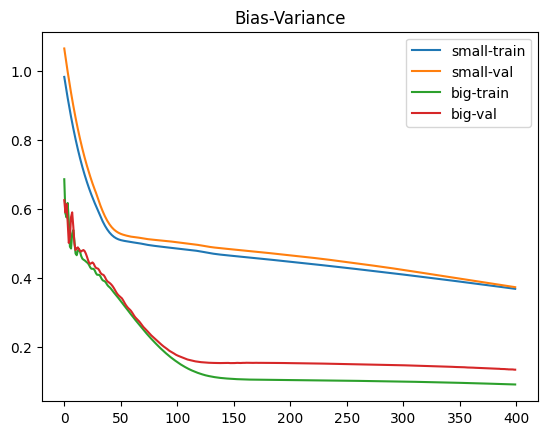

Small Test MSE: 0.3862417936325073
Big   Test MSE: 0.1343836784362793


In [ ]:
# 4차시 보강 실습: Bias-Variance 감각 익히기
import torch, math, random
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1) 데이터: 사인파 + 잡음 -> 회귀 문제
torch.manual_seed(0)
N = 600
x = torch.linspace(-3*math.pi, 3*math.pi, N).unsqueeze(1)
y = torch.sin(x) + 0.2*torch.randn_like(x)

# 데이터 분할(X_train, X_val, X_test)
X_train, X_temp, y_train, y_temp = train_test_split(x.numpy(), y.numpy(), test_size=0.4, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# tensor로 변환
X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
X_val,   y_val   = torch.tensor(X_val,   dtype=torch.float32), torch.tensor(y_val,   dtype=torch.float32)
X_test,  y_test  = torch.tensor(X_test,  dtype=torch.float32), torch.tensor(y_test,  dtype=torch.float32)

# 2) 두 모델: 저용량(작은 MLP) vs 고용량(큰 MLP)
def make_mlp(hidden):
    return nn.Sequential(
        nn.Linear(1, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, 1)
    )

small = make_mlp(hidden=8)   # 고편향/저분산 경향
big   = make_mlp(hidden=128) # 저편향/고분산 경향

def train(model, Xtr, ytr, Xva, yva, epochs=600, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    tr_hist, va_hist = [], []
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        pred = model(Xtr)
        loss = loss_fn(pred, ytr)
        loss.backward()
        opt.step()

        # 평가용 모드 전환
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xva), yva).item()
        tr_hist.append(loss.item()); va_hist.append(v)
    return tr_hist, va_hist

tr_s, va_s = train(small, X_train, y_train, X_val, y_val, epochs=400)
tr_b, va_b = train(big, X_train, y_train, X_val, y_val, epochs=400)

plt.figure(); plt.plot(tr_s, label='small-train'); plt.plot(va_s, label='small-val')
plt.plot(tr_b, label='big-train'); plt.plot(va_b, label='big-val'); plt.legend(); plt.title('Bias-Variance')
plt.show()

# 최종 테스트 MSE
def mse(model, X, y):
    with torch.no_grad():
        return nn.MSELoss()(model(X), y).item()
print("Small Test MSE:", mse(small, X_test, y_test))
print("Big   Test MSE:", mse(big,   X_test, y_test))


In [ ]:
# eos